## Nazira Tukeyeva | Homework 5

In [20]:
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging

In [2]:
df=pd.read_csv('swissrain100.csv') # 100 mean rainfall measurements taken in stations across Switzerland
df.head()

,x,y,value,altitude
0,6.351499,46.544351,151,682
1,6.406433,46.710820,255,813
2,6.574735,46.737855,79,436
3,6.599386,46.904837,191,833
4,6.607163,46.835829,194,579


In [3]:
df1=pd.read_csv('swissrain367.csv') # locations (367) where the rainfall needs to be predicted
df1.head()

,x,y,value,altitude
0,6.101519,46.469874,215.0,1272
1,6.101597,46.213918,167.0,389
2,6.120175,46.440006,271.0,1359
3,6.143198,46.262396,166.0,392
4,6.183946,46.556997,263.0,1276


In [4]:
print(df.shape)
print(df1.shape)

(100, 4)
(367, 4)


As can be seen, in both datasets we have got 'x' and 'y' coordinates, value (rainfall mean) and altitude.

#### Task: Use the following spatial interpolation methods: NN or IDW, ordinary kriging and universal kriging using provided altitude. Compare the models using mean squared error metric. Provide plots

In [5]:
# getting coords and values for train data
coords = df[['x', 'y']].values 
vals = df['value'].values
altitude = df['altitude'].values

# getting coords and altitudes for preds
predCoords = df1[['x', 'y']].values
predAltitude = df1['altitude'].values

In [12]:
# Method 1: IDW
def idw(coords, vals, predCoords, power=2):
    dist_matrix = distance_matrix(predCoords, coords)
    weights = 1.0 / (dist_matrix ** power)
    weights /= weights.sum(axis=1)[:, None]
    idw_values = np.dot(weights, vals)
    return idw_values

idw_pred = idw(coords, vals, predCoords)

In [18]:
# idw_pred

In [21]:
# Method 2: Ordinary kriging 
OK = OrdinaryKriging(coords[:, 0], coords[:, 1], vals, variogram_model='linear')
ok_pred, ss = OK.execute('points', predCoords[:, 0], predCoords[:, 1])

In [33]:
# Method 3: Universal kriging
UK = UniversalKriging(coords[:, 0], coords[:, 1], vals, variogram_model='linear')
uk_pred, ss = UK.execute('points', predCoords[:, 0], predCoords[:, 1])

Above, I have performed 3 different spatial interpolation methods: 
    
    1. IDW
    
    2. Ordinary Kriging
    
    3. Universal Kriging
    
Next on, to analyze its performance power, I'll use MSE as the evaluation metric to compare the results.

In [35]:
# MSE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
idw_errors = []
ok_errors = []
uk_errors = []

In [40]:
for train_index, test_index in kf.split(coords):
    X_train, X_test = coords[train_index], coords[test_index]
    y_train, y_test = vals[train_index], vals[test_index]
    alt_train, alt_test = altitude[train_index], altitude[test_index]

    idw_pred = idw(X_train, y_train, X_test)
    idw_errors.append(mean_squared_error(y_test, idw_pred))
    
    OK = OrdinaryKriging(X_train[:, 0], X_train[:, 1], y_train, variogram_model='linear')
    ok_pred, ss = OK.execute('points', X_test[:, 0], X_test[:, 1])
    ok_errors.append(mean_squared_error(y_test, ok_pred))
    
    UK = UniversalKriging(X_train[:, 0], X_train[:, 1], y_train, variogram_model='linear')
    uk_pred, ss = UK.execute('points', X_test[:, 0], X_test[:, 1])
    uk_errors.append(mean_squared_error(y_test, uk_pred))

# MSE for each method
avg_idw_error = np.mean(idw_errors)
avg_ok_error = np.mean(ok_errors)
avg_uk_error = np.mean(uk_errors)

In [39]:
print('MSE for IDW:', avg_idw_error)
print('MSE for Ordinary Kriging:', avg_ok_error)
print('MSE for Universal Kriging:', avg_uk_error)

MSE for IDW: 6233.343248691548
MSE for Ordinary Kriging: 9436.665784777162
MSE for Universal Kriging: 10197.929756421177


As can be seen from the results above, the lowest, yet the best result (minimum error), was achieved using IDW interpolation method. Below, I've a plot showing visually the error distributions for each method.

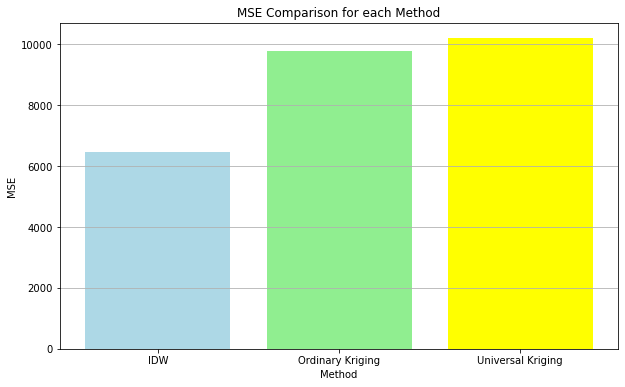

In [65]:
mse_values = [avg_idw_error, avg_ok_error, avg_uk_error]
methods = ['IDW', 'Ordinary Kriging', 'Universal Kriging']

plt.figure(figsize=(10, 6))
plt.bar(methods, mse_values, color=['lightblue', 'lightgreen', 'yellow'])
plt.title('MSE Comparison for each Method')
plt.xlabel('Method')
plt.ylabel('MSE')
plt.grid(axis='y')
plt.show()

C:\Users\Nazira\AppData\Local\Temp\ipykernel_9544\2582348408.py:4: RuntimeWarning: divide by zero encountered in true_divide
  weights = 1.0 / (dist_matrix ** power)
C:\Users\Nazira\AppData\Local\Temp\ipykernel_9544\2582348408.py:5: RuntimeWarning: invalid value encountered in true_divide
  weights /= weights.sum(axis=1)[:, None]


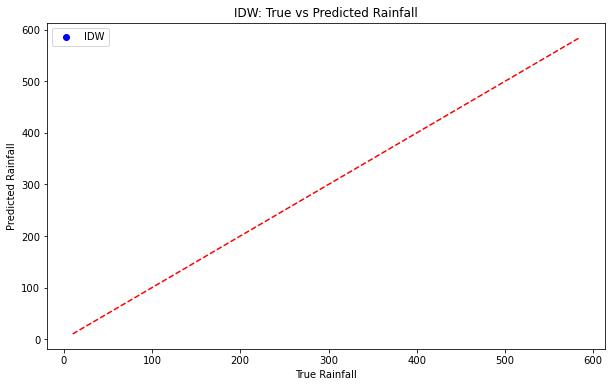

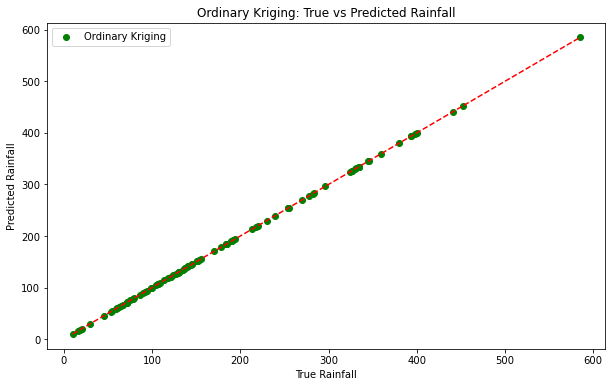

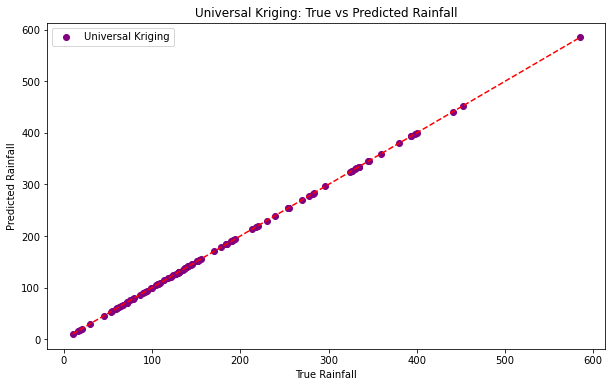

In [81]:
# IDW
plt.figure(figsize=(10, 6))
plt.scatter(vals, idw(coords, vals, coords), color='blue', label='IDW')
plt.plot([min(vals), max(vals)], [min(vals), max(vals)], color='red', linestyle='--')
plt.title('IDW: True vs Predicted Rainfall')
plt.xlabel('True Rainfall')
plt.ylabel('Predicted Rainfall')
plt.legend()
plt.show()

# Ordinary Kriging
plt.figure(figsize=(10, 6))
plt.scatter(vals, ok_pred, color='green', label='Ordinary Kriging')
plt.plot([min(vals), max(vals)], [min(vals), max(vals)], color='red', linestyle='--')
plt.title('Ordinary Kriging: True vs Predicted Rainfall')
plt.xlabel('True Rainfall')
plt.ylabel('Predicted Rainfall')
plt.legend()
plt.show()

# Universal Kriging
plt.figure(figsize=(10, 6))
plt.scatter(vals, uk_pred, color='purple', label='Universal Kriging')
plt.plot([min(vals), max(vals)], [min(vals), max(vals)], color='red', linestyle='--')
plt.title('Universal Kriging: True vs Predicted Rainfall')
plt.xlabel('True Rainfall')
plt.ylabel('Predicted Rainfall')
plt.legend()
plt.show()

In this task, I've performed 3 interpolation methods. The plots above show the distribution between predicted and true values for each method. By analyzing the MSE results, we can suggest that the IDW method has the highest performance power for this data.

### Problem 2 (Optional) - my attempt to solve it

In [115]:
df = pd.read_csv('odra.csv')
df.head()

,stationid,name,water,hyear,hmonth,day,level,month
0,151170030,TRESTNO,Odra (1),1980,1,1,314,11
1,151170030,TRESTNO,Odra (1),1980,1,2,304,11
2,151170030,TRESTNO,Odra (1),1980,1,3,298,11
3,151170030,TRESTNO,Odra (1),1980,1,4,320,11
4,151170030,TRESTNO,Odra (1),1980,1,5,288,11


In [116]:
df.shape

(15706, 8)

In [117]:
df.drop(columns=['water', 'name'], inplace=True) # unnecessary cols for analysis

In [118]:
df.rename(columns={'hyear': 'year'}, inplace=True)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.set_index('date')
df.head()

,stationid,year,hmonth,day,level,month
date,,,,,,
1980-11-01,151170030,1980,1,1,314,11
1980-11-02,151170030,1980,1,2,304,11
1980-11-03,151170030,1980,1,3,298,11
1980-11-04,151170030,1980,1,4,320,11
1980-11-05,151170030,1980,1,5,288,11


In [126]:
blockMaxima = df['level'].resample('A').max() # maxima by years

In [122]:
from scipy.stats import genextreme
shape, loc, scale = genextreme.fit(blockMaxima) # GEV distribution

The estimation of standard error is done by using bootstrapping method: resampling, fitting the GEV distribution and calculating final estimate for standard error paramater.

In [123]:
# task: standard error estimation
def stderr_est(data, n_bootstrap=1000):
    boot_shapes = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_shape, _, _ = genextreme.fit(sample)
        boot_shapes.append(boot_shape)
    return np.std(boot_shapes)

shape_std_err = stderr_est(blockMaxima)
(shape, shape_std_err)

(-0.1901324552937959, 2.0664335955239257)

So, by looking at the shape parameter we get -0.190 whuch means that it's rather light tail distribution. As for standard error is 2.067 which implies that there's uncertainty in estimating of shape parameter.

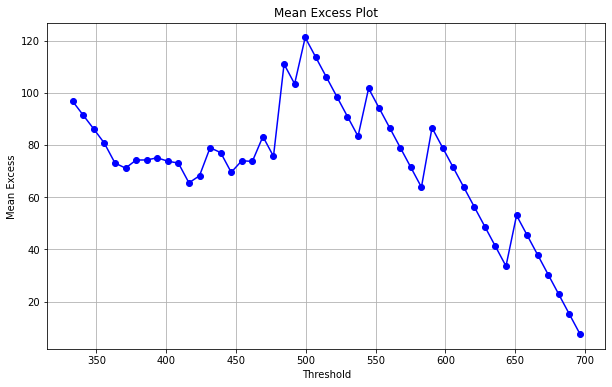

In [127]:
# task: mean excess plot
mean_excess = []
thresholds = np.linspace(blockMaxima.min(), blockMaxima.max(), 50)
for u in thresholds:
    excess = blockMaxima[blockMaxima > u] - u
    mean_excess.append(excess.mean())

plt.figure(figsize=(10, 6))
plt.plot(thresholds, mean_excess, marker='o', linestyle='-', color='b')
plt.xlabel('Threshold')
plt.ylabel('Mean Excess')
plt.title('Mean Excess Plot')
plt.grid(True)
plt.show()

The plot above shows mean excess over different threshold values (x-threshold, y-avg excess). Since, it mainly shows downward trend (starting from t=500), then it suggests that it's a light-tailed distribution.